# Data Cleaning

Data cleaning is one of the most important steps in a data analysis workflow.

 > sometimes this is the most important part! [Surveys](https://www.pragmaticinstitute.com/resources/articles/data/overcoming-the-80-20-rule-in-data-science/) reveal that ML practitioners spend on average about 80% of their time on finding, cleaning, and organizing the data!!

 Common steps include:

 - ensuring data are correctly imported
 - check format consistency
 - checking missing values
  - discard missing values
  - impute missing values
 - check for outliers and decide how to treat them

## Boston housing dataset

In this tutorial we are going to use the **Boston housing price dataset**.  Most precisely, we are going to use a slightly different version to highlight some important aspects and procedures when working with real data.

The data was originally published by Harrison, D. and Rubinfeld, D.L. *Hedonic prices and the demand for clean air*, J. Environ. Economics & Management, vol.5, 81-102, 1978.

### Miscellaneous Details

The dataset is small in size with only **559 cases and 16 features** carrying information about house prices in the Boston area:


        CRIM - per capita crime rate by town
        ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
        INDUS - proportion of non-retail business acres per town.
        CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
        NOX - nitric oxides concentration (parts per 10 million)
        RM - average number of rooms per dwelling
        AGE - proportion of owner-occupied units built prior to 1940
        DIS - weighted distances to five Boston employment centres
        RAD - index of accessibility to radial highways
        TAX - full-value property-tax rate per $10,000
        PTRATIO - pupil-teacher ratio by town
        B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        LSTAT - % lower status of the population
        NPC - Number of nearby parks in the house area
        RRS - a score that measures how recently was the house renovated
        MEDV - Median value of owner-occupied homes in $1000's

This dataset is typically used for two prototasks:
 - **NOX regression**, in which the nitrous oxide level is to be predicted;
 - and **MEDV regression**, in which the median value of a home is to be predicted

For more information, check here: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# first: get the data from this url: https://l.infn.it/aml-b2425-boston-housing
# second upload it to drive

from google.colab import files
uploaded = files.upload()

Saving dataset-data-cleaning.csv to dataset-data-cleaning.csv


In [ ]:
# now check if/where the file is available

!ls

dataset-data-cleaning.csv  drive  sample_data


In [ ]:
# file_path = "boston-houses-edited.csv"
file_path = "dataset-data-cleaning.csv"

df = pd.read_csv(file_path)
df.head()

ParserError: Error tokenizing data. C error: Expected 3 fields in line 3, saw 5


#### What is going wrong???

## Debugging

Let's try to fix it...

> **any ideas?**

In [ ]:
# let's try to fix it...any ideas?

## Exclude metadata

Now that we know the starting line, let's try to read the data portion only.

After visual inspection, we noticed that there is some metadata on top of the file.

--> skip rows

In [ ]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

lines[:30]

[" The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic\n",
 " prices and the demand for clean air', J. Environ. Economics & Management,\n",
 " vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics\n",
 " ...', Wiley, 1980.   N.B. Various transformations are used in the table on\n",
 ' pages 244-261 of the latter.\n',
 '\n',
 ' Variables in order:\n',
 ' CRIM     per capita crime rate by town\n',
 ' ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n',
 ' INDUS    proportion of non-retail business acres per town\n',
 '" CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)"\n',
 ' NOX      nitric oxides concentration (parts per 10 million)\n',
 ' RM       average number of rooms per dwelling\n',
 ' AGE      proportion of owner-occupied units built prior to 1940\n',
 ' DIS      weighted distances to five Boston employment centres\n',
 ' RAD      index of accessibility to radial highways\n',
 ' T

In [ ]:
for lineno, line in enumerate(lines[:30]):
  print(lineno, "\t", line)

0 	  The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic

1 	  prices and the demand for clean air', J. Environ. Economics & Management,

2 	  vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics

3 	  ...', Wiley, 1980.   N.B. Various transformations are used in the table on

4 	  pages 244-261 of the latter.

5 	 

6 	  Variables in order:

7 	  CRIM     per capita crime rate by town

8 	  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.

9 	  INDUS    proportion of non-retail business acres per town

10 	 " CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)"

11 	  NOX      nitric oxides concentration (parts per 10 million)

12 	  RM       average number of rooms per dwelling

13 	  AGE      proportion of owner-occupied units built prior to 1940

14 	  DIS      weighted distances to five Boston employment centres

15 	  RAD      index of accessibility to radial highways

16 	  TAX     

In [ ]:
for lineno, line in enumerate(lines[:30]):
  print(lineno, f"first_char: '{line[0]}'" "\t", line.encode('utf-8'))

0 first_char: ' '	 b" The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic\n"
1 first_char: ' '	 b" prices and the demand for clean air', J. Environ. Economics & Management,\n"
2 first_char: ' '	 b" vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics\n"
3 first_char: ' '	 b" ...', Wiley, 1980.   N.B. Various transformations are used in the table on\n"
4 first_char: ' '	 b' pages 244-261 of the latter.\n'
5 first_char: '
'	 b'\n'
6 first_char: ' '	 b' Variables in order:\n'
7 first_char: ' '	 b' CRIM     per capita crime rate by town\n'
8 first_char: ' '	 b' ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n'
9 first_char: ' '	 b' INDUS    proportion of non-retail business acres per town\n'
10 first_char: '"'	 b'" CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)"\n'
11 first_char: ' '	 b' NOX      nitric oxides concentration (parts per 10 million)\n'
12 first_char: ' '	 b' RM       avera

In [ ]:
for lineno, line in enumerate(lines[:30]):
  # print(lineno, f"first_char: '{line[0]}'" "\t", line)
  if line[0].isdigit():
    data_start_index = lineno
    break

print(f"data starts at line {data_start_index}")

data starts at line 22


In [ ]:
df = pd.read_csv(file_path, skiprows=data_start_index)
df.head(20)

,0,00632 18,0 2,31 0,0 0,538 6,575 65,2 4,09 1,0 296,0 15,3
0,396,9 4,98 24,0 1 nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,02731 0,0 7,07 0,0 0,469 6,421 78,9 4,9671 2,0 242,0 17,8.0
2,396,9 9,14 21,6 1 nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,02729 0,0 7,07 0,0 0,469 7,185 61,1 4,9671 2,0 242,0 17,8.0
4,392,83 4,03 34,7 1 28,502375918853485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,03237 0,0 2,18 0,0 0,458 6,998 45,8 6,0622 3,0 222,0 18,7.0
6,394,63 2,94 33,4 1 39,526114398359525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,06905 0,0 2,18 0,0 0,458 7,147 54,2 6,0622 3,0 222,0 18,7.0
8,396,9 5,33 36,2 1 nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,02985 0,0 2,18 0,0 0,458 6,43 58,7 6,0622 3,0 222,0 18,7.0


In [ ]:
# df = pd.read_csv(file_path, skiprows=data_start_index, header=None, decimal=',' , sep="  ")


In [ ]:
# df = pd.read_csv(file_path, skiprows=data_start_index, header=None, decimal=',' , sep="  ")
# df.head(20)

<ipython-input-20-34d8faef8cf1>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(file_path, skiprows=data_start_index, header=None, decimal=',' , sep="  ")


,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538000,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469000,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,"21,6 1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469000,7.185,61.1,4.9671,2.0,242.0,17.8
5,392.83000,4.03,34.7,1,28.502376,NaN,NaN,NaN,NaN,NaN,NaN
6,0.03237,0.00,2.18,0.0,0.458000,6.998,45.8,6.0622,3.0,222.0,18.7
7,394.63000,2.94,33.4,1,39.526114,NaN,NaN,NaN,NaN,NaN,NaN
8,0.06905,0.00,2.18,0.0,0.458000,7.147,54.2,6.0622,3.0,222.0,18.7
9,396.90000,5.33,36.2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After playing with skiprows, header, sep/delimiter and decimal, we managed to get data without errors, but the format still doesn't look as we'd expected.

> data rows are split over 2 lines, therefore **we need to clean/reformat the file before using pandas.**

In [ ]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# get data portion
data_lines = lines[data_start_index:]
data_lines[:10]

['0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3\n',
 '396,9  4,98  24,0  1  nan\n',
 '0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8\n',
 '396,9  9,14  21,6 1  nan\n',
 '0,02729  0,0  7,07  0,0  0,469  7,185  61,1  4,9671  2,0  242,0  17,8\n',
 '392,83  4,03  34,7  1  28,502375918853485\n',
 '0,03237  0,0  2,18  0,0  0,458  6,998  45,8  6,0622  3,0  222,0  18,7\n',
 '394,63  2,94  33,4  1  39,526114398359525\n',
 '0,06905  0,0  2,18  0,0  0,458  7,147  54,2  6,0622  3,0  222,0  18,7\n',
 '396,9  5,33  36,2  1  nan\n']

In [ ]:
# got first rows (odd lines)
data_lines[0:10:2]

['0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3\n',
 '0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8\n',
 '0,02729  0,0  7,07  0,0  0,469  7,185  61,1  4,9671  2,0  242,0  17,8\n',
 '0,03237  0,0  2,18  0,0  0,458  6,998  45,8  6,0622  3,0  222,0  18,7\n',
 '0,06905  0,0  2,18  0,0  0,458  7,147  54,2  6,0622  3,0  222,0  18,7\n']

In [ ]:
# got second rows (even lines)
data_lines[1:11:2]

['396,9  4,98  24,0  1  nan\n',
 '396,9  9,14  21,6 1  nan\n',
 '392,83  4,03  34,7  1  28,502375918853485\n',
 '394,63  2,94  33,4  1  39,526114398359525\n',
 '396,9  5,33  36,2  1  nan\n']

In [ ]:
# get paired row values
i = 1
for first_line, second_line in zip(data_lines[0::2], data_lines[1::2]):
  print(f"\n{first_line=}")
  print(f"{second_line=}")
  i += 1
  if i > 2:
    break


first_line='0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3\n'
first_line=0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3

second_line='396,9  4,98  24,0  1  nan\n'

first_line='0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8\n'
first_line=0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8

second_line='396,9  9,14  21,6 1  nan\n'


In [ ]:
# join lines into rows
" ".join([first_line[:-1], second_line]) # Note: we strip newlines char ("\n") from end of first lines

'0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8 396,9  9,14  21,6 1  nan\n'

In [ ]:
# all at once
merged_lines = [" ".join([first_line[:-1], second_line]) for first_line, second_line in zip(data_lines[0::2], data_lines[1::2])]
merged_lines[:10]


['0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3 396,9  4,98  24,0  1  nan\n',
 '0,02731  0,0  7,07  0,0  0,469  6,421  78,9  4,9671  2,0  242,0  17,8 396,9  9,14  21,6 1  nan\n',
 '0,02729  0,0  7,07  0,0  0,469  7,185  61,1  4,9671  2,0  242,0  17,8 392,83  4,03  34,7  1  28,502375918853485\n',
 '0,03237  0,0  2,18  0,0  0,458  6,998  45,8  6,0622  3,0  222,0  18,7 394,63  2,94  33,4  1  39,526114398359525\n',
 '0,06905  0,0  2,18  0,0  0,458  7,147  54,2  6,0622  3,0  222,0  18,7 396,9  5,33  36,2  1  nan\n',
 '0,02985  0,0  2,18  0,0  0,458  6,43  58,7  6,0622  3,0  222,0  18,7 394,12  5,21  28,7  1  nan\n',
 '0,08829  12,5  7,87  0,0  0,524  6,012  66,6  5,5605  5,0  311,0  15,2 395,6  12,43  22,9  1  27,084296107758334\n',
 '0,14455  12,5  7,87  0,0  0,524  6,172  96,1  5,9505  5,0  311,0  15,2 396,9  19,15  27,1  1  nan\n',
 '0,21124  12,5  7,87  0,0  0,524  5,631  100,0  6,0821  5,0  311,0  15,2 386,63  29,93  16,5  1  16,384638267641442\n',
 '0,17004  12,

In [ ]:
merged_lines[0].encode('utf-8')

b'0,00632  18,0  2,31  0,0  0,538  6,575  65,2  4,09  1,0  296,0  15,3 396,9  4,98  24,0  1  nan\n'

In [ ]:
merged_lines[1].split()

['0,02731',
 '0,0',
 '7,07',
 '0,0',
 '0,469',
 '6,421',
 '78,9',
 '4,9671',
 '2,0',
 '242,0',
 '17,8',
 '396,9',
 '9,14',
 '21,6',
 '1',
 'nan']

In [ ]:
"\t".join(line.split())

'0,05515\t0,0\t18,1\tnan\t0,713\t5,709\t94,5\t7,0379\tnan\t243,0\t20,2\tnan\t4,03\tnan\t1\t15,300788532902315'

In [ ]:
output_file = "boston-houses-cleaned.csv"

with open(output_file, "w", encoding="utf-8") as f:
  # for line in merged_lines:
    # cleaned_line = line.replace("  ", "\t")
    # cleaned_line = "\t".join(line.split())
    # f.write(cleaned_line + "\n")
#
  f.writelines(merged_lines)

In [ ]:
df = pd.read_csv(output_file, header=None, decimal=',' , sep="\t")
print(f"{df.shape=}")
df.head()

df.shape=(559, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0,1.0,NaN
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6,1.0,NaN
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,1.0,28.502376
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,1.0,39.526114
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2,1.0,NaN


## Final result

In [ ]:
# final result
colnames = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX",
           "PTRATIO", "B", "LSTAT", "NPC", "RRS","MEDV"]
df.columns = colnames


sorted_colnames = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX",
           "PTRATIO", "B", "LSTAT", "NPC", "RRS","MEDV"]

df[sorted_colnames].head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,NPC,RRS,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0,1.0,NaN
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6,1.0,NaN
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,1.0,28.502376
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,1.0,39.526114
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2,1.0,NaN


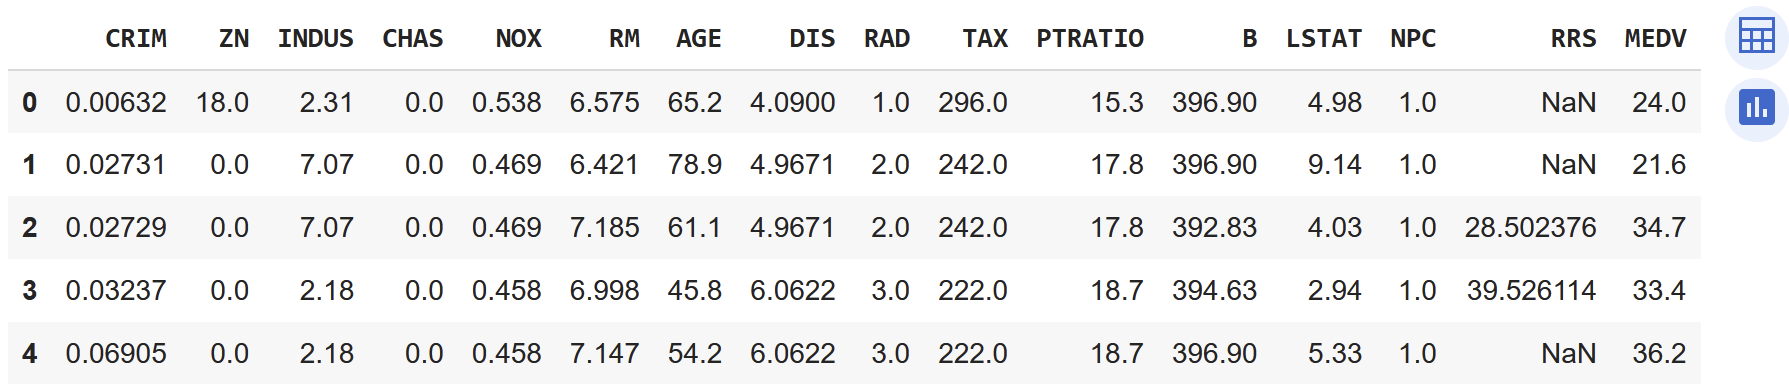

### Saving cleaned data

> Do not forget to save the result after all this cleaning!!!

In [ ]:
# should have named "my-final-precious-data.awesome"
output_file = "boston-houses-final.csv"
df[sorted_colnames].to_csv(output_file, sep=",", decimal=".", index=False)

## Hands-on Exercise

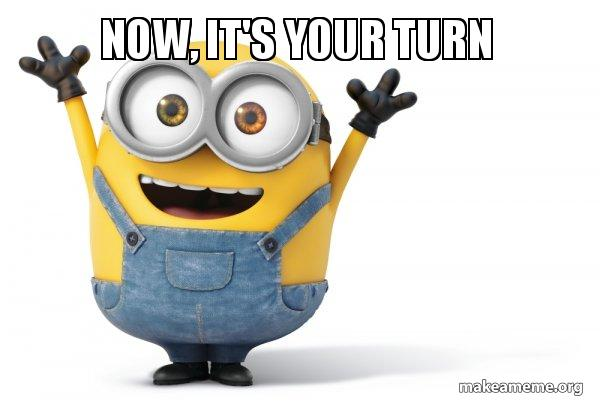

> Exercise: Perform some Exploratory Data Analysis (EDA). Take inspiration from steps 1-5 suggested at the top of the notebook, but be curious and feel free to deep down on aspects you find interesting!! (20 minutes)

More precisely:
 1. Check missing values
 1. Get an idea of univariate distributions
 - First produce a table with min, 10th, 25th, 50th, 75th, 90th and max quantiles
 - Plot a histogram per each feature
 3. Get a correlation matrix and plot a heatmap to visualize it
 4. Check outliers: plot a box plot per each feature and use it to visually inspect outliers

 5. Collect you insights in a report for documentation

> Post you insights here (create gdoc and paste statistics/plots you find most interesting, and note down some short comments/interpretations): https://drive.google.com/drive/folders/1avvQcoPeN_S6AXlx5huyBn0a04vSGjBr?usp=sharing

